In [1]:
from env import (
    MultiLeafThreadEnv,
    ThreadingConfig,
)
import torch
import random
from viz import draw_local_tree_sequence, draw_tree_edge_index
# from utils import _timed_tree_to_graph_full
import matplotlib.pyplot as plt

from utils import build_backbone_segments_from_reference
from viz import draw_local_tree_sequence
from utils import get_max_actions
from utils import MultiLeafState

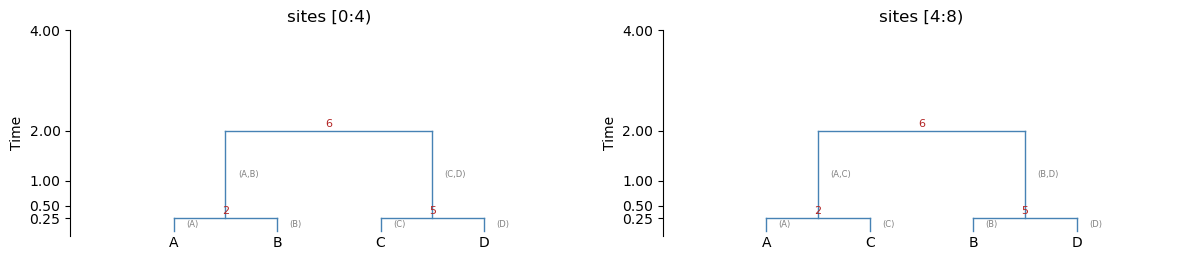

In [2]:
## First example
REFERENCE_FULL_TREES = [
    {
        "sites": (0, 4),
        # "tree": ("n", 2.0, ("n", 1.0, ("n", 1.0, 0, 1), 2), 3),
        "tree": ("n", 2.0, ("n", 0.25, 0, 1), ("n", 0.25, 2, 3)),
    },
    {
        "sites": (4, 8),
        "tree": ("n", 2.0, ("n", 0.25, 0, 2), ("n", 0.25, 1, 3)),
    },
]

GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0], #A
        [0, 0, 0, 0, 1, 1, 1, 1], #B
        [1, 1, 1, 1, 0, 0, 0, 0], #C
        [1, 1, 1, 1, 1, 1, 1, 1], #D
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)

## View this tree. 

full_tree_backbone = build_backbone_segments_from_reference(REFERENCE_FULL_TREES, focal_leaf=-1)
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)


In [3]:
multi_env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
env = MultiLeafThreadEnv(multi_env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)

## Threading Process of Sample A. 


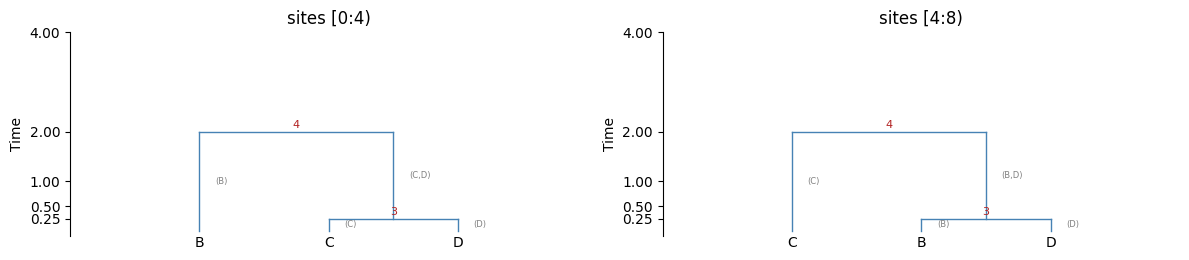

In [14]:
## Threading Process of Sample A. 
env.reset() ## Initial state. removes first sample in the orderfrom the backbone
draw_local_tree_sequence(env._inner_env.backbone_segments, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)


### Action space upper bound for threading sample A 

In [15]:
## Max actions space for threading a sample into the local tree. this gives mathematically distinct, but doesn't merge to get polytomies. 
print("Action space upper bound for threading sample A is", get_max_actions(len(LEAF_NAMES)-1, time_grid=TIME_GRID))

Action space upper bound for threading sample A is 15


### Valid actions

In [16]:
st = env.reset()
valid_acts = env.valid_actions(st)
print("number of valid actions for the given input ARG .. local tree is", len(valid_acts))

number of valid actions for the given input ARG .. local tree is 8


### Possible Actions space for single Site

In [17]:
import ipywidgets as widgets
from IPython.display import display

## Possible Actions space for single Site


def plot_action(i):
    st = env.reset()
    k = env.describe_action(st, valid_acts[i], leaf_names=LEAF_NAMES)
    print(k)
    
    choice = env._inner_env.site_choices[st.inner_state.site_index][valid_acts[i]]
    # print(choice.branch_signature, choice.time_value)

    st, reward, done = env.step(st, valid_acts[i])
    local_trees = env._inner_env.snapshot_state(st.inner_state)
    draw_local_tree_sequence(local_trees, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)

widgets.interact(plot_action, i=widgets.IntSlider(min=0, max=len(valid_acts)-1, step=1, value=0, description='Action Index'))


interactive(children=(IntSlider(value=0, description='Action Index', max=7), Output()), _dom_classes=('widget-…

<function __main__.plot_action(i)>

## Threading one single sample across the sequence


[leaf A] site 0 -> branch root @ t4=4.00 [start] (1, 2, 3) 4.0
[leaf A] site 1 -> branch (C) @ t0=0.25 [recomb] (2,) 0.25
[leaf A] site 2 -> branch (C,D) @ t1=0.50 [recomb] (2, 3) 0.5
[leaf A] site 3 -> branch (C) @ t0=0.25 [recomb] (2,) 0.25
[leaf A] site 4 -> branch (C) @ t0=0.25 [recomb] (2,) 0.25
[leaf A] site 5 -> branch (B,D) @ t1=0.50 [recomb] (1, 3) 0.5
[leaf A] site 6 -> branch (C) @ t1=0.50 [recomb] (2,) 0.5
[leaf A] site 7 -> branch (B,D) @ t2=1.00 [recomb] (1, 3) 1.0


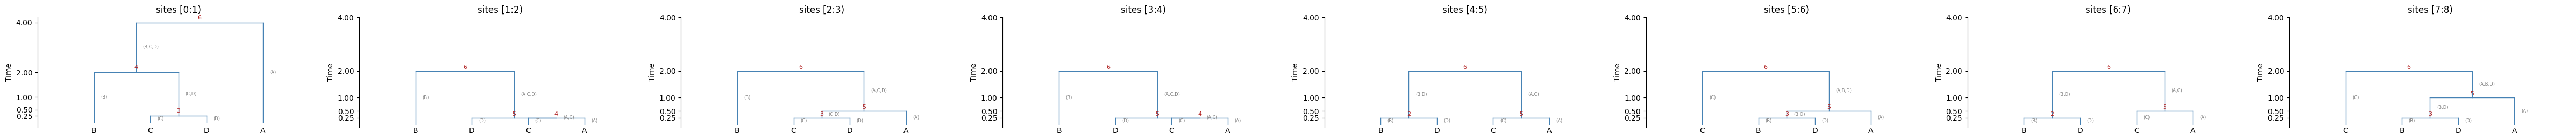

In [18]:
## Threading one single sample across the sequence


def thread_single_sample(env, leaf_names, rand=True):
    st = env.reset()
    actions = []
    inner_done = False
    while not inner_done:
        valid_acts = env.valid_actions(st)
        if rand:
            action = random.choice(valid_acts)
        else: 
            action = 0
        
        k = env.describe_action(st, action, leaf_names=leaf_names)
        choice = env._inner_env.site_choices[st.inner_state.site_index][action]
        print(k, choice.branch_signature, choice.time_value)
        actions.append(action)
        inner_next, inner_reward, inner_done = env._inner_env.step(
            st.inner_state, action
        )
        st = MultiLeafState(
            current_full_trees=st.current_full_trees,
            leaves_threaded=st.leaves_threaded,
            current_focal_leaf=st.current_focal_leaf,
            inner_state=inner_next
        )
    new_full_trees = env._update_full_trees(
            st.current_full_trees,
            st.current_focal_leaf,
            inner_next.choices,
            env._inner_env,
        )
    return new_full_trees

full_tree_backbone = build_backbone_segments_from_reference(thread_single_sample(env, leaf_names=LEAF_NAMES, rand=True), focal_leaf=-1, )
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)



### Thread sample for all sites across the sequence. 


In [9]:
### Thread sample for all sites across the sequence. 

st = env.reset()
actions = []

# inner_next, inner_reward, inner_done = env._inner_env.step(
#             st.inner_state, action_idx
#         )
while not env.is_terminal(st):
    valid_acts = env.valid_actions(st)
    action = random.choice(valid_acts)
    # action = valid_acts[0]
    k = env.describe_action(st, action, leaf_names=LEAF_NAMES)
    choice = env._inner_env.site_choices[st.inner_state.site_index][action]
    print(k, choice.branch_signature, choice.time_value)
    actions.append(action)
    st, reward, done = env.step(st, action)


[leaf A] site 0 -> branch (C,D) @ t2=1.00 [start] (2, 3) 1.0
[leaf A] site 1 -> branch (B) @ t1=0.50 [recomb] (1,) 0.5
[leaf A] site 2 -> branch (B) @ t2=1.00 [stay] (1,) 1.0
[leaf A] site 3 -> branch (C,D) @ t2=1.00 [recomb] (2, 3) 1.0
[leaf A] site 4 -> branch (C) @ t3=2.00 [recomb] (2,) 2.0
[leaf A] site 5 -> branch (C) @ t3=2.00 [stay] (2,) 2.0
[leaf A] site 6 -> branch (C) @ t1=0.50 [stay] (2,) 0.5
[leaf A] site 7 -> branch (B,D) @ t1=0.50 [recomb] (1, 3) 0.5
[leaf B] site 0 -> branch (C,D) @ t2=1.00 [start] (2, 3) 1.0
[leaf B] site 1 -> branch (C,D) @ t3=2.00 [stay] (2, 3) 2.0
[leaf B] site 2 -> branch root @ t4=4.00 [recomb] (0, 2, 3) 4.0
[leaf B] site 3 -> branch (A) @ t0=0.25 [recomb] (0,) 0.25
[leaf B] site 4 -> branch (D) @ t3=2.00 [recomb] (3,) 2.0
[leaf B] site 5 -> branch (C) @ t0=0.25 [recomb] (2,) 0.25
[leaf B] site 6 -> branch (C) @ t0=0.25 [stay] (2,) 0.25
[leaf B] site 7 -> branch (C) @ t3=2.00 [recomb] (2,) 2.0
[leaf C] site 0 -> branch (B) @ t0=0.25 [start] (1,) 0.

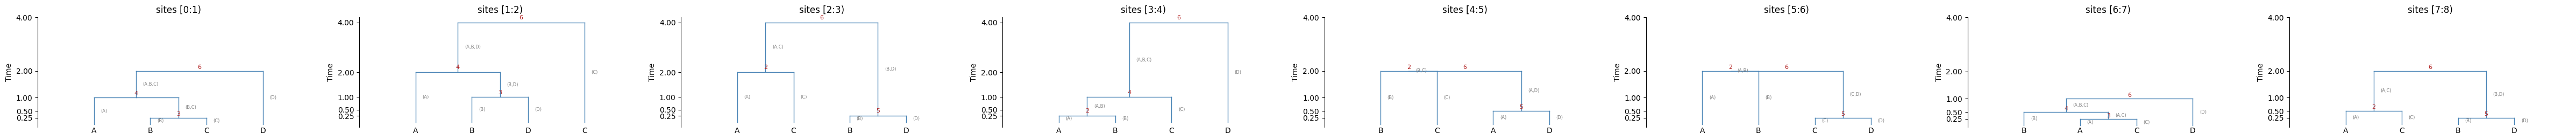

In [10]:
full_tree_backbone = build_backbone_segments_from_reference(st.current_full_trees, focal_leaf=-1)
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)
